# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [1]:
### LIBRARY IMPORTS ###
import os
import numpy as np
import tensorflow as tf
import keras.applications as ka
import keras

## Task 1
Implement the my_team()function 

In [2]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [
        (11301406, 'Joshua', 'Rapsey'),
        (11290803, 'Joshua', 'Hentscher'),
        (11631996, 'Cooper', 'Smith')
    ]

In [3]:
my_team()

[(11301406, 'Joshua', 'Rapsey'),
 (11290803, 'Joshua', 'Hentscher'),
 (11631996, 'Cooper', 'Smith')]

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [4]:
def load_data(path='small_flower_dataset'):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Returns the images as a
    numpy array and the associated class labels as a numpy array.
    '''
    class_names = [
    name for name in sorted(os.listdir(path))
    if os.path.isdir(os.path.join(path, name)) and not name.startswith('.')
    ]
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')
    images = []
    labels = []

    for class_index, class_name in enumerate(class_names):
        class_path = os.path.join(path, class_name)
        for file_name in sorted(os.listdir(class_path)):
            file_path = os.path.join(class_path, file_name)
            if os.path.isfile(file_path) and file_name.lower().endswith(image_extensions):
                image_bytes = tf.io.read_file(file_path)
                image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
                image = tf.image.resize(image, (224, 224))
                images.append(image.numpy())
                labels.append(class_index)

    images = ka.mobilenet_v2.preprocess_input(np.asarray(images, dtype=np.float32))
    labels = np.asarray(labels, dtype=np.int64)
    return images, labels

In [5]:
dataset = load_data()

2026-05-24 08:00:45.618452: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [6]:
def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    The split is performed in a stratified way so each class keeps a similar
    proportion in the train, evaluation, and test sets.
    """
    X = np.asarray(X)
    Y = np.asarray(Y)
    rng = np.random.default_rng()

    train_indices = []
    eval_indices = []
    test_indices = []

    for class_value in np.unique(Y):
        class_indices = np.where(Y == class_value)[0]
        if randomize:
            class_indices = class_indices.copy()
            rng.shuffle(class_indices)

        class_size = len(class_indices)
        remaining_required = 2 if eval_set and class_size >= 3 else 1 if (not eval_set and class_size >= 2) else 0
        train_count = int(round(train_fraction * class_size))
        train_count = max(0, min(train_count, class_size - remaining_required))

        remaining_indices = class_indices[train_count:]
        if eval_set:
            eval_count = len(remaining_indices) // 2
            test_count = len(remaining_indices) - eval_count
            train_indices.extend(class_indices[:train_count])
            eval_indices.extend(remaining_indices[:eval_count])
            test_indices.extend(remaining_indices[eval_count:eval_count + test_count])
        else:
            train_indices.extend(class_indices[:train_count])
            test_indices.extend(remaining_indices)

    if randomize:
        rng.shuffle(train_indices)
        rng.shuffle(eval_indices)
        rng.shuffle(test_indices)

    train_set = (X[train_indices], Y[train_indices])
    test_set = (X[test_indices], Y[test_indices])

    if eval_set:
        eval_set = (X[eval_indices], Y[eval_indices])
        return train_set, eval_set, test_set

    return train_set, test_set

In [7]:
train_set, eval_set, test_set = split_data(dataset[0], dataset[1], 0.6, randomize=True, eval_set=True)

Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

The data was split using a stratified 60/20/20 train/evaluation/test split.
Images were shuffled within each class before splitting so the five flower
classes stay balanced across all partitions.

## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [8]:
def load_model():
    '''
    Load in a model using the tf.keras.applications model and return it.
    The returned model is a pretrained MobileNetV2 network with the ImageNet
    weights loaded.
    '''
    return ka.MobileNetV2(weights='imagenet', include_top=True, input_shape=(224, 224, 3))
    

In [9]:
model = load_model()

## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [10]:
def transfer_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    learning_rate, momentum, nesterov = parameters
    train_images, train_labels = train_set
    eval_images, eval_labels = eval_set

    for layer in model.layers:
        layer.trainable = False

    classifier = keras.layers.Dense(5, activation='softmax', name='flower_predictions')(model.layers[-2].output)
    model = keras.Model(inputs=model.input, outputs=classifier)
    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=momentum,
            nesterov=nesterov,
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(eval_images, eval_labels),
        epochs=10,
        batch_size=32,
        verbose=1,
    )
    return model, history

In [11]:
import os
print(sorted(os.listdir('small_flower_dataset')))

['.ipynb_checkpoints', 'daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [12]:
model, history = transfer_learning(train_set, eval_set, load_model(), (0.01, 0.0, False))

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.4233 - loss: 1.4024 - val_accuracy: 0.6700 - val_loss: 1.0307
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.7183 - loss: 0.8649 - val_accuracy: 0.7750 - val_loss: 0.7767
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.7933 - loss: 0.6616 - val_accuracy: 0.7950 - val_loss: 0.6637
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.8317 - loss: 0.5507 - val_accuracy: 0.8150 - val_loss: 0.6075
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - accuracy: 0.8650 - loss: 0.4822 - val_accuracy: 0.8200 - val_loss: 0.5666
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.8767 - loss: 0.4317 - val_accuracy: 0.8250 - val_loss: 0.5422
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.8900 - loss: 0.3959 - val_accuracy: 0.8350 - val_loss: 0.5276
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.8983 - loss: 0.3658 - val_accuracy: 0.

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

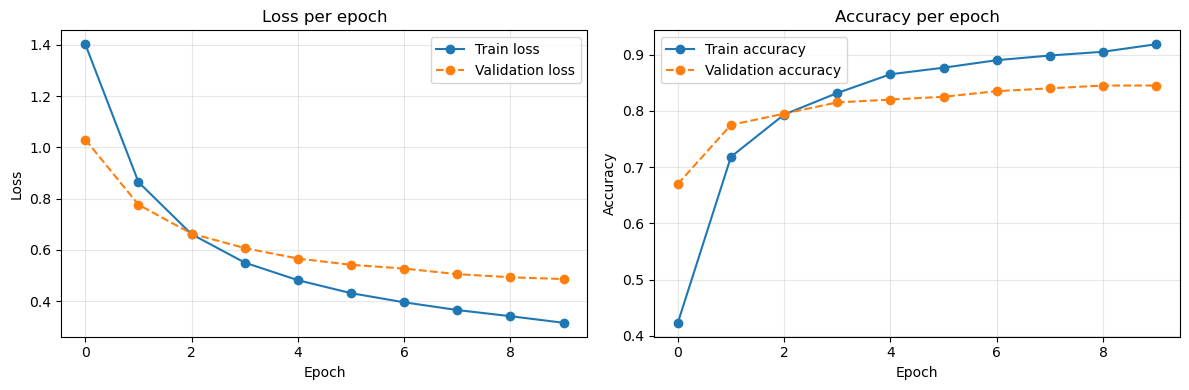

In [13]:
## Your Code
import matplotlib.pyplot as plt

def plot_training(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    #loss
    ax1.plot(history.history['loss'],     label='Train loss',      marker='o')
    ax1.plot(history.history['val_loss'], label='Validation loss', marker='o', linestyle='--')
    ax1.set_title('Loss per epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    #accuracy
    ax2.plot(history.history['accuracy'],     label='Train accuracy',      marker='o')
    ax2.plot(history.history['val_accuracy'], label='Validation accuracy', marker='o', linestyle='--')
    ax2.set_title('Accuracy per epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_training(history)

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell


Training with lr=0.001
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.2117 - loss: 1.8978 - val_accuracy: 0.2350 - val_loss: 1.7021
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.2617 - loss: 1.7076 - val_accuracy: 0.2800 - val_loss: 1.5609
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.3183 - loss: 1.5687 - val_accuracy: 0.3750 - val_loss: 1.4529
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.3683 - loss: 1.4592 - val_accuracy: 0.4400 - val_loss: 1.3628
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.4167 - loss: 1.3661 - val_accuracy: 0.4900 - val_loss: 1.2842
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.4767 - loss: 1.2850 - val_accuracy: 0.5250 - val_loss: 1.2162
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.5167 - loss: 1.2151 - val_accuracy: 0.5700 - val_loss: 1.1566
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.5583 - loss: 1

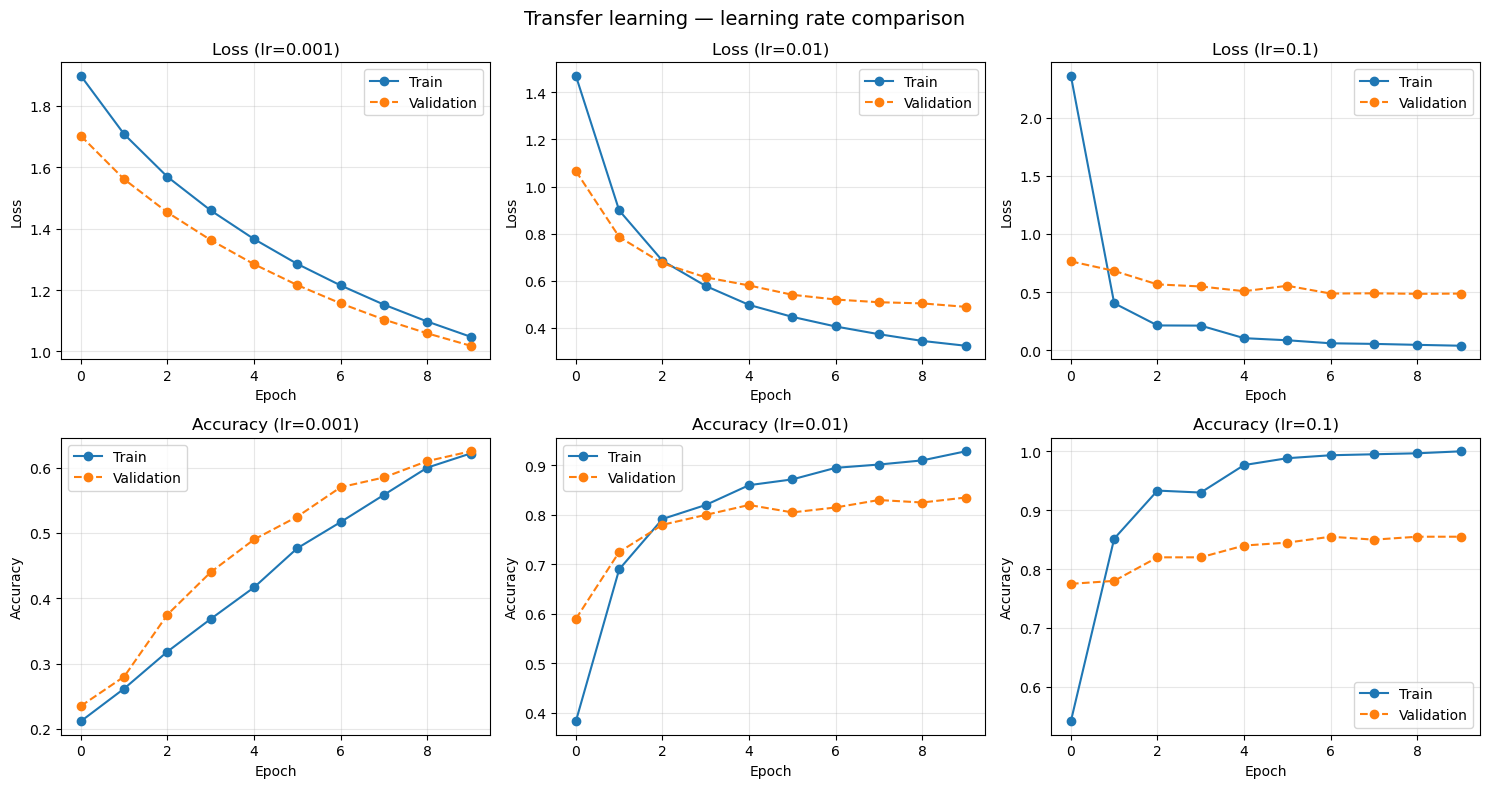

In [14]:
## Your code

learning_rates = [0.001, 0.01, 0.1]
histories = {}

for lr in learning_rates:
    print(f"\nTraining with lr={lr}")
    _, histories[lr] = transfer_learning(train_set, eval_set, load_model(), (lr, 0.0, False))

def plot_lr_comparison(histories):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    learning_rates = list(histories.keys())

    for col, lr in enumerate(learning_rates):
        h = histories[lr].history

        # Loss
        axes[0, col].plot(h['loss'],     label='Train',      marker='o')
        axes[0, col].plot(h['val_loss'], label='Validation', marker='o', linestyle='--')
        axes[0, col].set_title(f'Loss (lr={lr})')
        axes[0, col].set_xlabel('Epoch')
        axes[0, col].set_ylabel('Loss')
        axes[0, col].legend()
        axes[0, col].grid(True, alpha=0.3)

        # Accuracy
        axes[1, col].plot(h['accuracy'],     label='Train',      marker='o')
        axes[1, col].plot(h['val_accuracy'], label='Validation', marker='o', linestyle='--')
        axes[1, col].set_title(f'Accuracy (lr={lr})')
        axes[1, col].set_xlabel('Epoch')
        axes[1, col].set_ylabel('Accuracy')
        axes[1, col].legend()
        axes[1, col].grid(True, alpha=0.3)

    plt.suptitle('Transfer learning — learning rate comparison', fontsize=14)
    plt.tight_layout()
    plt.savefig('lr_comparison.png', dpi=150)
    plt.show()

plot_lr_comparison(histories)

### Task 8 Analysis and discussion


## Learning rate comparison

**lr=0.001 (too slow):**
Training is stable but very slow. Both loss and accuracy are still clearly trending
after 10 epochs and haven't converged. Loss only reaches ~1.0 and accuracy ~63%,
suggesting the model needs far more epochs to fully train at this rate. Interestingly,
validation accuracy is slightly ahead of training accuracy throughout, which is unusual
and likely reflects the small dataset size and how the split landed.

**lr=0.01 (best):**
The best balance of speed and stability. Loss drops sharply in the first 3 epochs then
smoothly plateaus. Training accuracy reaches ~93% and validation accuracy stabilises
around ~85%, showing good generalisation. The train/val gap is reasonable and there are
no signs of instability.

**lr=0.1 (too aggressive):**
Converges the fastest but shows clear overfitting. Training accuracy reaches 100% while
validation accuracy plateaus at ~85%. The train loss collapses near zero while validation
loss stays around 0.5, indicating the model is memorising the training set rather than
generalising. The large learning rate takes big steps that overfit the classifier head
to the training data.

**Conclusion:**
lr=0.01 is the optimal choice for this task. lr=0.001 underfits within 10 epochs and
lr=0.1 overfits. A learning rate of 0.01 gives the best generalisation as measured by
validation accuracy.

## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

In [23]:
## Your code

#best model!
best_model, best_history = transfer_learning(train_set, eval_set, load_model(), (0.01, 0.0, False))

test_images, test_labels = test_set
predictions = best_model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

#confusion matrix
def plot_confusion_matrix(true_labels, pred_labels):
    class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
    n = len(class_names)
    
    cm = np.zeros((n, n), dtype=int)
    for true, pred in zip(true_labels, pred_labels):
        cm[true, pred] += 1
    
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im)
    
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title('Confusion matrix — test set (lr=0.01)')
    
    for i in range(n):
        for j in range(n):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center', color=color)
    
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - accuracy: 0.4717 - loss: 1.3491 - val_accuracy: 0.6100 - val_loss: 1.0718
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.7200 - loss: 0.8384 - val_accuracy: 0.7450 - val_loss: 0.8120
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8000 - loss: 0.6474 - val_accuracy: 0.7550 - val_loss: 0.7006
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.8417 - loss: 0.5444 - val_accuracy: 0.7650 - val_loss: 0.6413
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.8533 - loss: 0.4811 - val_accuracy: 0.7900 - val_loss: 0.5971
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.8817 - loss: 0.4301 - val_accuracy: 0.8000 - val_loss: 0.5683
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.8917 - loss: 0.3901 - val_accuracy: 0.8150 - val_loss: 0.5525
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.9067 - loss: 0.3595 - val_accuracy: 0.

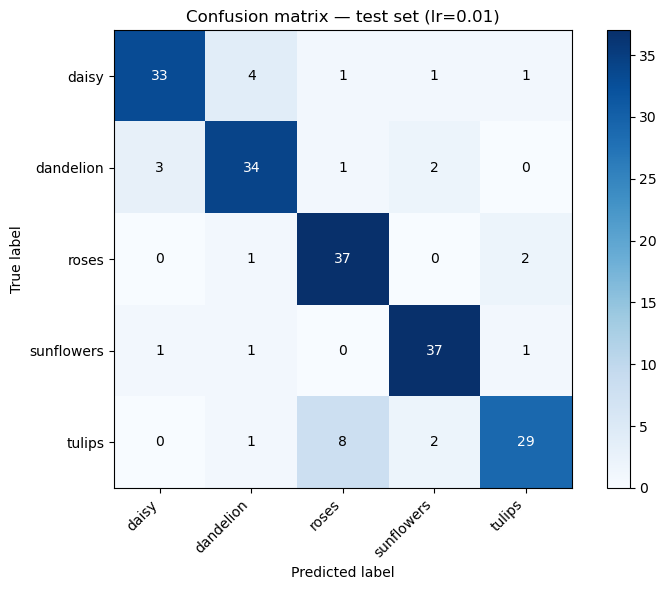

In [24]:
plot_confusion_matrix(test_labels, predicted_labels)

## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [16]:
## Your code

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [17]:
def k_fold_validation(features, ground_truth, classifier, k=2):
    '''
    Inputs:
        - features: np.ndarray of features in the dataset
        - ground_truth: np.ndarray of class values associated with the features
        - fit_func: f
        - classifier: class object with both fit() and predict() methods which
        can be applied to subsets of the features and ground_truth inputs.
        - predict_func: function, calling predict_func(features) should return
        a numpy array of class predictions which can in turn be input to the 
        functions in this script to calculate performance metrics.
        - k: int, number of sub-sets to partition the data into. default is k=2
    Outputs:
        - avg_metrics: np.ndarray of shape (3, c) where c is the number of classes.
        The first row is the average precision for each class over the k
        validation steps. Second row is recall and third row is f1 score.
        - sigma_metrics: np.ndarray, each value is the standard deviation of 
        the performance metrics [precision, recall, f1_score]
    '''
    
    #split data
    ### YOUR CODE HERE ###
    
    #go through each partition and use it as a test set.
    for partition_no in range(k):
        #determine test and train sets
        ### YOUR CODE HERE###
        
        #fit model to training data and perform predictions on the test set
        classifier.fit(train_features, train_classes)
        predictions = classifier.predict(test_features)
        
        #calculate performance metrics
        ### YOUR CODE HERE###
    
    #perform statistical analyses on metrics
    ### YOUR CODE HERE###
    
    raise NotImplementedError
    return avg_metrics, sigma_metrics

In [18]:
## Your code
# xx = k_fold_validation(xx, xx, xx, xx)

Comment on the results and any differences with the previous test-train split. 
Repeat with two different values for k and comment on the results. 

### Comments and analysis

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  

In [19]:
## Code

### Report

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [20]:
def accelerated_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform accelerated transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    raise NotImplementedError
    return model


Plot and comment on the results and differences against the standard implementation of transfer learning. 

In [21]:
## Code

### Your Comments:

## Task 14
Use the results of all experiments to make suggestions for future work and recommendations for parameter values to anyone else who may be interested in a similar implementation of transfer learning. 

### Your answer: